In [36]:
# === Notebook path and directory configuration ===
from pathlib import Path
import sys

CWD = Path.cwd().resolve()
if CWD.name == "diagnostic":
    DIAGNOSTIC_DIR = CWD
elif (CWD / "diagnostic").is_dir():
    DIAGNOSTIC_DIR = CWD / "diagnostic"
else:
    DIAGNOSTIC_DIR = next((p for p in [CWD, *CWD.parents] if p.name == "diagnostic"), CWD.parent)

if str(DIAGNOSTIC_DIR) not in sys.path:
    sys.path.insert(0, str(DIAGNOSTIC_DIR))

model_outpath = Path("/compyfs/zhan391/v3_dart_cda_scratch")
dart_outpath = model_outpath

DIAG_OUT_DIR = Path("/compyfs/www/zhan391/e3sm_dart/diag_out")
DIAG_DATA_DIR = DIAG_OUT_DIR / "data"
DIAG_FIGURE_DIR = DIAG_OUT_DIR / "figure"

DIAG_DATA_DIR.mkdir(parents=True, exist_ok=True)
DIAG_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

import os
import string 
import warnings
import logging
from collections import defaultdict
import os
from typing import Dict, Mapping, Sequence, Optional

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import (
    MaxNLocator,
    ScalarFormatter,
    LogLocator,
    LogFormatter,
)

# === Plotting ===
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
from matplotlib.patches import Polygon
from matplotlib import ticker
from matplotlib.ticker import FuncFormatter

from util.dart_obs_diag import (
    DartObsDiagReader
)

# === Suppress warnings globally ===
warnings.filterwarnings("ignore")

In [37]:
from configs.analysis_da_experiment_config import extract_obs_diag_config

# User setup: edit this dictionary when experiment names, runs, aliases, periods,
# or diagnostic sets change. The shared helper only validates and builds paths.
USER_EXPERIMENTS = {
    "CAM80-S0": {
        "run": "f.e21.FHIST_BGC.f09_025.CAM6assim.011",
        "key": "dart_en80",
        "alias": "CAM6EN80",
        "period": "2011121600-2012010100",
    },
    "CAM80-S1": {
        "run": "f.e22.FHIST_BGC.f09_025.CAM6assim.011",
        "key": "dart_en80",
        "alias": "CAM6EN80S1",
        "period": "2012050100-2012060100",
    },
    "CTRL10-S0": {
        "run": "CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en10",
        "alias": "CTRLEN10",
        "period": "2011121600-2012010100",
    },
    "DART10-S0": {
        "run": "DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en10",
        "alias": "DARTEN10",
        "period": "2011121600-2012010100",
    },
    "DART20-S0": {
        "run": "DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en20",
        "alias": "DARTEN20",
        "period": "2011121600-2012010100",
    },
    "DART40INF0p6-S0": {
        "run": "DARTEN40_INF0p6_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en40",
        "alias": "DARTEN40",
        "period": "2011121600-2012010100",
    },
    "DART40-S0": {
        "run": "DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en40",
        "alias": "DARTEN40",
        "period": "2011121600-2012010100",
    },
    "DART40-S1": {
        "run": "DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en40",
        "alias": "DARTEN40S1",
        "period": "2012050100-2012060100",
    },
}

# User setup: change this tuple when the available diagnostic sets change.
USER_DIAG_SETS = ("obs_seq", "obs_diag", "obs_common", "closest_member", "cam6_common")

# Optional layer for temporary add/update/remove changes. Set an experiment to None
# here to remove it without touching USER_EXPERIMENTS.
USER_EXPERIMENT_OVERRIDES = {}


def extract_exp_info(exp_name: str = None) -> dict:
    return extract_obs_diag_config(
        exp_name=exp_name,
        experiments=USER_EXPERIMENTS,
        data_path=dart_outpath,
        diag_sets=USER_DIAG_SETS,
        experiment_overrides=USER_EXPERIMENT_OVERRIDES,
    )

In [38]:
class ObsDiagPlotter:
    """
    Helper for plotting DART obs_diag metrics.

    Key ideas:
    - var_dict may be a "wrapper" {var_key: inner_cfg} or the inner_cfg itself.
    - For grid plots we often don't need full var_dict; _varcfg() falls back to
      a sane default (lev_type='pressure', generic y-limits).
    """

    def __init__(
        self,
        var: Optional[str],
        var_dict: Optional[Mapping],
        data_dict: Optional[Mapping],
        fig_path: str,
        plevstr: Optional[Sequence],
        regnam: Optional[str] = None,
        hs: float = 0.5,
        ws: float = 0.5
    ):
        self.var = var
        self.var_dict = dict(var_dict) if var_dict is not None else {}
        self.data_dict = dict(data_dict) if data_dict is not None else {}
        self.fig_path = fig_path
        self.plevstr = list(plevstr) if plevstr is not None else []
        self.regnam = regnam
        self.hs = hs
        self.ws = ws
        self.fontz = 12
        self._prepare_common()

    # ------------------------------------------------------------------
    # internal helpers
    # ------------------------------------------------------------------
    def _prepare_common(self):
        self.cmap = {
            "blue":   "#377eb8",
            "orange": "#ff7f00",
            "green":  "#4daf4a",
            "pink":   "#f781bf",
            "brown":  "#a65628",
            "purple": "#984ea3",
            "gray":   "#999999",
            "red":    "#e41a1c",
            "yellow": "#dede00",
        }

    def _set_axes_limits(self, ax, xlim=None, ylim=None, yticks=None, xticks=None):
        if xlim is not None:
            ax.set_xlim(*xlim)
        if ylim is not None:
            ax.set_ylim(*ylim)
        if yticks is not None:
            ax.set_yticks(yticks)
        if xticks is not None:
            ax.set_xticks(xticks)

    def _varcfg(self) -> Dict:
        """
        Return the internal var-config.

        Recognized cases:
        - var_dict is an inner config with 'y1aix'/'y2aix'
        - var_dict is {var_key: inner_config}
        Otherwise, return a safe default (pressure levels).
        """
        vd = self.var_dict or {}

        # Case 1: already an inner config
        if isinstance(vd, dict) and "y1aix" in vd:
            return vd

        # Case 2: wrapper {var_key: inner_cfg}
        if isinstance(vd, dict) and len(vd) == 1:
            inner = next(iter(vd.values()))
            if isinstance(inner, dict) and "y1aix" in inner:
                return inner

        # Fallback
        return {
            "lev_type": "pressure",
            "y1aix": [0, 10],
            "y2aix": [0, 100],
        }

    # ------------------------------------------------------------------
    # configuration + preprocessing
    # ------------------------------------------------------------------
    def check_flat_lev_consistency(self, lev_dict: Mapping[str, Sequence[float]]):
        """
        Ensure all variables share exactly the same level list.
        """
        if not lev_dict:
            raise ValueError("lev_dict is empty; cannot check consistency.")

        ref_var = next(iter(lev_dict))
        reference = list(lev_dict[ref_var])
        for var, lev in lev_dict.items():
            if list(lev) != reference:
                raise ValueError(
                    f"Inconsistent pressure level list for variable '{var}'.\n"
                    f"Expected: {reference}\nFound:    {list(lev)}"
                )
        print("All level lists are consistent across variables.")
        return reference

    def build_ts_var_dict(
        self,
        var_key: Optional[str] = None,
        name: Optional[str] = None,
        y1axis: Optional[Sequence[float]] = None,
        y2axis: Optional[Sequence[float]] = None,
    ) -> Dict[str, Dict]:
        """
        Build a basic var_dict entry for time-series / profile plotting.
        """
        var_key = var_key or "RADIOSONDE_U"
        name = name or "RADIOSONDE_U_WIND_COMPONENT"
        entry = {
            "name": name,
            "lev_type": "pressure",
            "CopySpread": "totalspread",
            "CopyRMSE": "rmse",
            "CopyNposs": "Nposs",
            "CopyNused": "Nused",
            "type1": "guess",
            "type2": "VPguess",
            "type3": "guess_RankHist",
            "y1aix": list(y1axis) if y1axis is not None else [0, 10],
            "y2aix": [0, 100],
            "y1aix0": list(y2axis) if y2axis is not None else [0, 10],
            "y2aix0": [0, 100],
        }
        return {var_key: entry}

    def compute_experiment_means(self, data_dict, diagnostic_keys_to_average):
        """
        Average selected diagnostics across variables for each experiment.

        diagnostic_keys_to_average: list of metrics to average (e.g. ["rmse", "spread"]).
        Other keys (e.g. lev, time, *_str, rejection when not used) are
        carried through if consistent; if inconsistent, the first value is kept
        with a warning instead of raising an error.
        """
        if not data_dict:
            raise ValueError("data_dict is empty; cannot compute means.")

        sample_var_data = next(iter(data_dict.values()))
        experiments = list(sample_var_data.keys())
        all_diagnostic_keys = next(iter(sample_var_data.values())).keys()
        mean_dict = {}

        for exp in experiments:
            mean_dict[exp] = {}
            for key in all_diagnostic_keys:
                if key in diagnostic_keys_to_average:
                    # --- keys we want to average across variables ---
                    valid_data = []
                    for var in data_dict:
                        entry = data_dict[var].get(exp, {}).get(key, None)
                        if (
                            isinstance(entry, np.ndarray)
                            and entry.size > 0
                            and not np.all(np.isnan(entry))
                        ):
                            valid_data.append(entry)
                    if valid_data:
                        try:
                            stacked = np.stack(valid_data, axis=0)
                            mean_array = np.nanmean(stacked, axis=0)
                        except ValueError:
                            shapes = [arr.shape for arr in valid_data]
                            print(
                                f"[WARN] Shape mismatch for '{key}' in '{exp}': {shapes}. "
                                f"Skipping mean for this key."
                            )
                            mean_array = None
                    else:
                        mean_array = None
                    mean_dict[exp][key] = mean_array
                else:
                    # --- keys we just want to carry through (time, lev, *_str, etc.) ---
                    values = [
                        data_dict[var][exp][key]
                        for var in data_dict
                        if exp in data_dict[var] and key in data_dict[var][exp]
                    ]
                    if not values:
                        mean_dict[exp][key] = None
                        continue

                    first_val = values[0]
                    # if they're all identical, good — just keep one
                    if all(np.array_equal(first_val, v) for v in values):
                        mean_dict[exp][key] = first_val
                    else:
                        # previously this raised; now just warn and keep the first
                        print(
                            f"[WARN] Inconsistent values for diagnostic key '{key}' "
                            f"in experiment '{exp}'. Using the first value and continuing."
                        )
                        mean_dict[exp][key] = first_val

        return mean_dict


    # ------------------------------------------------------------------
    # plotting
    # ------------------------------------------------------------------
    def plot_metric_profile_grid(
        self,
        all_var_data,
        metric_dict,
        xscale="linear",
        yscale="linear",
        xticks=None,
        yticks=None,
        show=True,
        save=True,
        panel_width=11,
        panel_height=7,
        fontz=12,
    ):
        """
        Plot vertical metric profiles in a grid:
        rows = metrics (rmse, spread, rejection),
        columns = variables (U, V, T, q, ...).
        """

        if not all_var_data:
            raise ValueError("all_var_data is empty; nothing to plot.")

        metrics = list(metric_dict.keys())
        metric_labels = []
        for m in metrics:
            md = metric_dict[m]
            if isinstance(md, dict):
                label = md.get("label") or md.get("name") or str(m)
            else:
                label = str(m)
            metric_labels.append(label)

        vars_list = list(all_var_data.keys())
        n_vars = len(vars_list)
        n_metrics = len(metrics)

        vc = self._varcfg()
        lev_label = {
            "pressure": "Pressure (hPa)",
            "height": "Height (m)",
            "model": "Model Level",
        }.get(vc.get("lev_type"), "Level")

        # ------------------------------------------------------
        # PASS 1: collect values and determine per-(var,metric) ranges
        # ------------------------------------------------------
        metric_values = {var: {m: {} for m in metrics} for var in vars_list}
        # now ranges depend on BOTH variable and metric
        metric_ranges = {
            var: {m: [np.inf, -np.inf] for m in metrics} for var in vars_list
        }

        # style map (shared across all panels)
        exp_names_example = next(iter(all_var_data.values()))["data_dict"].keys()
        exp_names_example = list(exp_names_example)
        color_list = plt.cm.tab10.colors
        marker_list = ["o", "s", "^", "v", "*", "D", "P", "X"]
        linestyle_list = ["-", "--", "-.", ":"]
        style_map = {
            exp: {
                "color": color_list[i % len(color_list)],
                "marker": marker_list[i % len(marker_list)],
                "linestyle": linestyle_list[i % len(linestyle_list)],
                "linewidth": 1.5 + 0.5 * (i % 3),
                "markersize": 8 + (i % 3) * 2,
            }
            for i, exp in enumerate(exp_names_example)
        }

        for var in vars_list:
            data_dict = all_var_data[var]["data_dict"]

            for exp, d in data_dict.items():
                lev = np.asarray(d["lev"])

                for metric in metrics:
                    if metric == "spread":
                        spread = np.clip(np.asarray(d["spread"]), 1e-6, None)
                        rmse = np.clip(np.asarray(d["rmse"]), 1e-6, None)
                        vals = spread / rmse
                    elif metric == "rejection":
                        vals = np.clip(np.asarray(d["rejection"]), 1e-3, None)
                    else:  # default: rmse
                        vals = np.clip(np.asarray(d["rmse"]), 1e-3, None)

                    metric_values[var][metric][exp] = (vals, lev)

                    vmin = float(np.nanmin(vals))
                    vmax = float(np.nanmax(vals))
                    if np.isfinite(vmin) and np.isfinite(vmax):
                        metric_ranges[var][metric][0] = min(metric_ranges[var][metric][0], vmin)
                        metric_ranges[var][metric][1] = max(metric_ranges[var][metric][1], vmax)

        # pad & clean ranges per (var, metric)
        for var in vars_list:
            for metric in metrics:
                vmin, vmax = metric_ranges[var][metric]
                if not np.isfinite(vmin) or not np.isfinite(vmax):
                    continue

                if vmax == vmin:
                    if vmax == 0.0:
                        vmax = 1.0
                    else:
                        vmin *= 0.9
                        vmax *= 1.1
                else:
                    pad = 0.1 * (vmax - vmin)
                    vmin -= pad
                    vmax += pad

                if vmin < 0:
                    vmin = 0.0

                metric_ranges[var][metric] = [vmin, vmax]

        # ------------------------------------------------------
        # PASS 2: plotting
        # ------------------------------------------------------
        fig, axes = plt.subplots(
            nrows=n_metrics,
            ncols=n_vars,
            figsize=(panel_width, panel_height),
            sharey=True,
        )

        if n_metrics == 1:
            axes = np.array([axes])
        if n_vars == 1:
            axes = axes.reshape(n_metrics, 1)

        panel_letters = list(string.ascii_lowercase)
        panel_idx = 0

        for r, (metric, mlabel) in enumerate(zip(metrics, metric_labels)):

            for c, var in enumerate(vars_list):
                ax = axes[r, c]

                data_dict = all_var_data[var]["data_dict"]
                unit = all_var_data[var]["unit"]

                for exp, (values, lev) in metric_values[var][metric].items():
                    style = style_map[exp]

                    lev = np.asarray(lev)
                    values = np.asarray(values)
                    sort_idx = np.argsort(lev)[::-1]  # descending pressure
                    lev = lev[sort_idx]
                    values = values[sort_idx]

                    ax.plot(
                        values,
                        lev,
                        label=exp,
                        color=style["color"],
                        marker=style["marker"],
                        linestyle=style["linestyle"],
                        linewidth=style["linewidth"],
                        markersize=style["markersize"],
                    )
                    
                    # --- NEW: vertical line at Spread/RMSE = 1.0 ---
                    if metric == "spread":
                        ax.axvline(
                            1.0,
                            color="gray",
                            linestyle="--",
                            linewidth=1.2,
                            alpha=0.7,
                            zorder=1,
                        )
                        
                ax.set_xscale(xscale)
                ax.set_yscale(yscale)

                if xscale == "linear":
                    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
                    ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
                else:
                    ax.xaxis.set_major_locator(LogLocator(base=10))
                    ax.xaxis.set_major_formatter(LogFormatter(base=10))

                if yscale == "linear":
                    ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
                    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
                else:
                    ax.yaxis.set_major_locator(LogLocator(base=10))
                    ax.yaxis.set_major_formatter(LogFormatter(base=10))

                # ⬅️ per-(var, metric) x-range here
                auto_xmin, auto_xmax = metric_ranges[var][metric]
                ax.set_xlim(auto_xmin, auto_xmax)

                if yticks is not None:
                    ax.set_yticks(yticks)
                if xticks is not None:
                    ax.set_xticks(xticks)

                # titles with panel letters
                if panel_idx < len(panel_letters):
                    panel_letter = f"({panel_letters[panel_idx]})"
                else:
                    panel_letter = f"({panel_idx})"
                title_text = f"{panel_letter}  {mlabel} ({var})"
                ax.set_title(title_text, fontsize=fontz * 1.1, pad=6, loc = "left")
                panel_idx += 1

                # bottom row x-labels
                ax.set_xlabel(f"{unit}", fontsize=fontz * 1.0)
                # no raw y-label; we use row labels instead
                if c == 0:
                    ax.set_ylabel("")

                ax.tick_params(which="minor", label1On=False)
                ax.tick_params(labelsize=fontz)

                
        # Shared legend below the full figure.
        handles, lab = axes[0, 0].get_legend_handles_labels()
        if handles:
            legend = fig.legend(
                handles,
                lab,
                loc="lower center",
                bbox_to_anchor=(0.5, 0.01),
                ncol=len(lab),
                fontsize=fontz,
                frameon=True,
                fancybox=False,
                framealpha=1.0,
                borderpad=0.45,
                handlelength=2.5,
                columnspacing=1.6,
            )
            legend.get_frame().set_edgecolor("black")
            legend.get_frame().set_linewidth(0.8)
            legend.get_frame().set_facecolor("white")

        # enforce pressure orientation
        if vc.get("lev_type") == "pressure":
            for ax in np.ravel(axes):
                ymin, ymax = ax.get_ylim()
                if ymin < ymax:
                    ax.set_ylim(ymax, ymin)

        plt.tight_layout(rect=(0, 0.08, 1, 1))
        plt.subplots_adjust(hspace=0.25, wspace=0.15, bottom=0.12)

        if show:
            plt.show()
        if save:
            os.makedirs(self.fig_path, exist_ok=True)
            reg_str = (self.regnam or "region").replace(" ", "_")
            fname = os.path.join(
                self.fig_path,
                f"{getattr(self, 'figure_prefix', 'fig_obs_profile_grid')}_{reg_str}.pdf",
            )
            fig.savefig(fname, bbox_inches="tight")
            plt.close(fig)

In [39]:
# === Profile workflow options ===
# Choose one of: "obs_space_s0", "obs_space_s1", "common_s0", "common_s1".
# PROFILE_MODE = "obs_space_s0"
# PROFILE_MODE = "obs_space_s1"
# PROFILE_MODE = "obs_space_s0"
PROFILE_MODE = "obs_space_s0"

REGION = "NH"
METRICS_TO_PLOT = ["rmse", "spread"]
SHOW = True
SAVE = True
XSCALE = "linear"
YSCALE = "linear"
PANEL_WIDTH = 16
PANEL_HEIGHT = 12
FONT_SIZE = 18

REGION_NAMES = {
    "NH": "Northern Hemisphere",
    "SH": "Southern Hemisphere",
    "Tropics": "Tropics",
    "NA": "North America",
    "Global": "global",
}

S0_EXPERIMENTS = ["CAM80-S0", "DART10-S0", "DART20-S0", "DART40-S0"]
S1_EXPERIMENTS = ["CAM80-S1", "DART40-S1"]

PROFILE_VARIABLES = {
    "U_WIND": {"lev": "plev", "dtype": "VPguess", "unit": "m $s^{-1}$", "name": "U"},
    "V_WIND": {"lev": "plev", "dtype": "VPguess", "unit": "m $s^{-1}$", "name": "V"},
    "Temperature": {"lev": "plev", "dtype": "VPguess", "unit": "$^\\circ$C", "name": "T"},
    "Humidity": {"lev": "plev", "dtype": "VPguess", "unit": "g kg$^{-1}$", "name": "Q"},
}

METRIC_CATALOG = {
    "rmse": {"name": "Root Mean Square Error (RMSE)", "label": "RMSE"},
    "spread": {"name": "Ratio of Spread to RMSE", "label": "Spread/RMSE"},
    "rejection": {"name": "Observation rejection rate", "label": "Rejection"},
}

PROFILE_MODE_CONFIGS = {
    "obs_space_s0": {
        "diag_set": "diag2",
        "experiments": S0_EXPERIMENTS,
        "figure_prefix": "fig_obs_diag_prof_grid",
    },
    "obs_space_s1": {
        "diag_set": "diag2",
        "experiments": S1_EXPERIMENTS,
        "figure_prefix": "fig_obs_diag_prof_grid",
    },
    "common_s0": {
        "diag_set": "diag5",
        "experiments": S0_EXPERIMENTS,
        "figure_prefix": "fig_obs_compare_prof_grid",
    },
    "common_s1": {
        "diag_set": "diag5",
        "experiments": S1_EXPERIMENTS,
        "figure_prefix": "fig_obs_compare_prof_grid",
    },
}

found match for variable U_WIND in Conventional: RADIOSONDE_U_WIND_COMPONENT
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/f.e21.FHIST_BGC.f09_025.CAM6assim.011/archive/dart_en80/dart_diagnostics/obs_diag/f.e21.FHIST_BGC.f09_025.CAM6assim.011.dart.e.eam_obs_diag_output.2011121600-2012010100.nc
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en10/dart_diagnostics/obs_diag/DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011121600-2012010100.nc
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en20/dart_diagnostics/obs_diag/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011121600-2012010100.nc
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en40/dart_diagnostics/obs_diag/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_

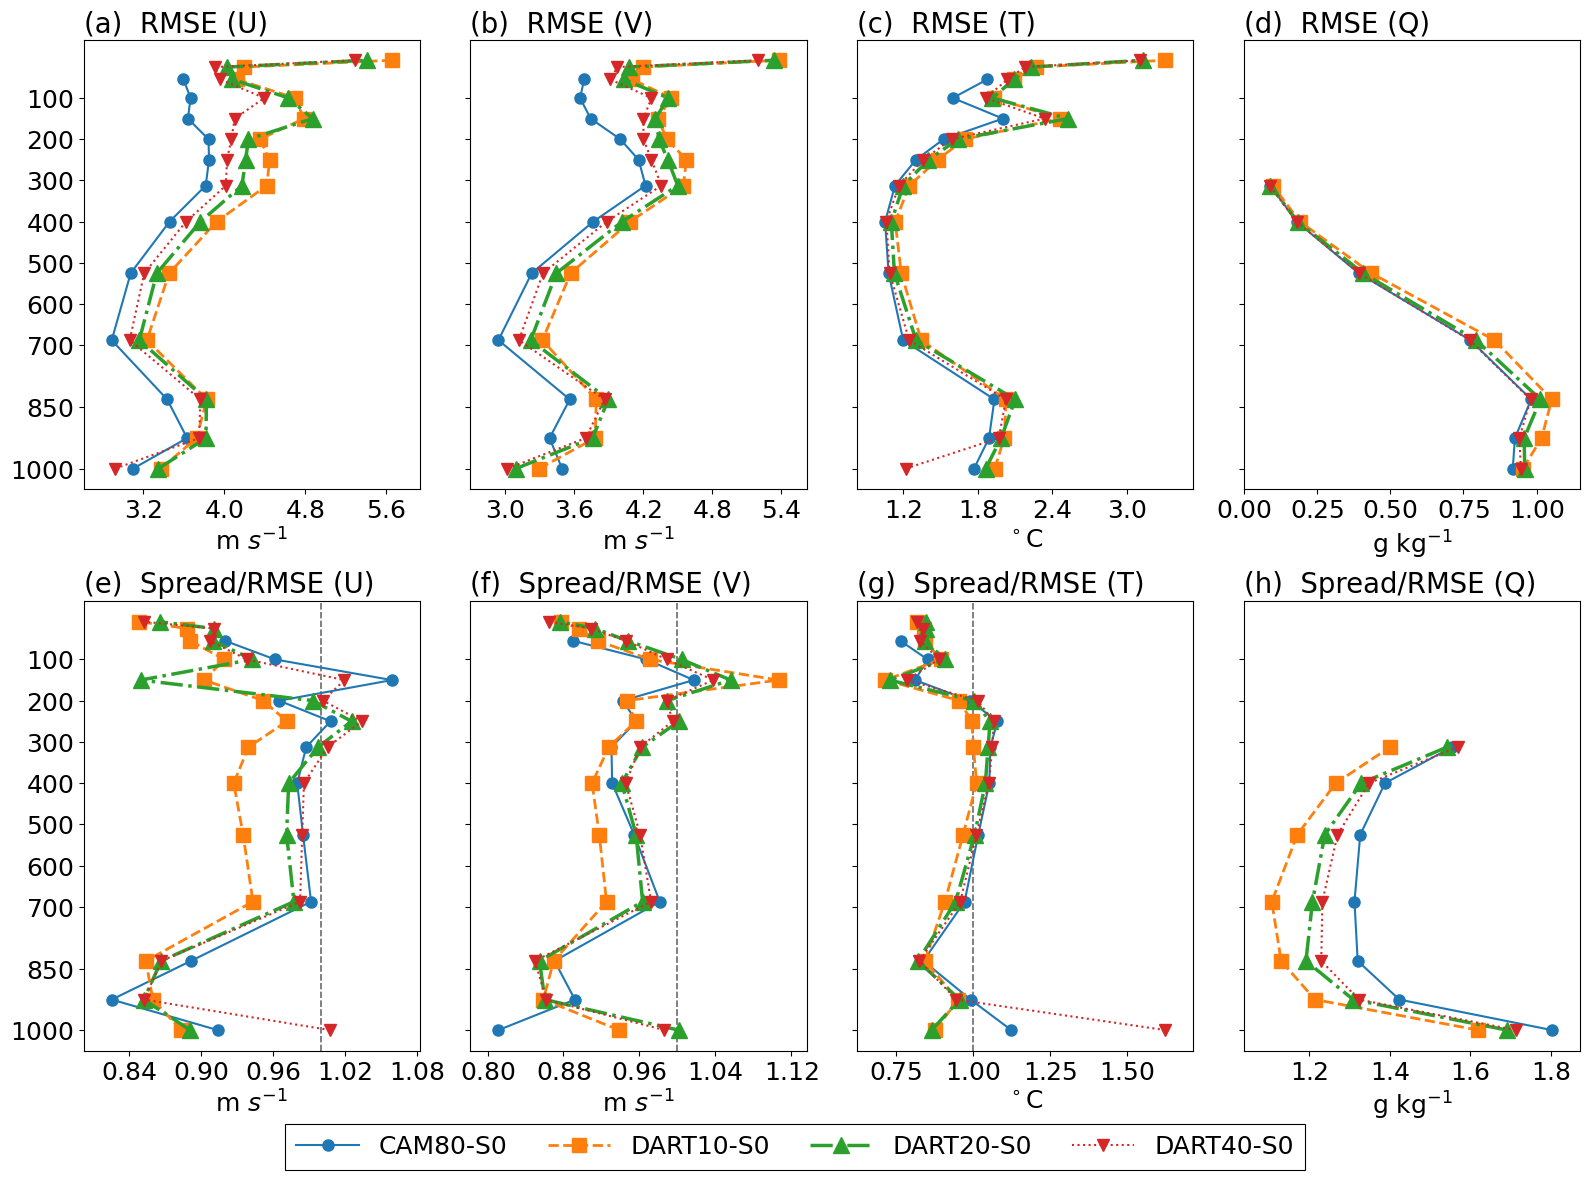

In [40]:
def _profile_ticks(xscale, yscale):
    if xscale == "log":
        xticks = [0.01, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 100]
    else:
        xticks = None

    if yscale == "log":
        yticks = [1000, 850, 700, 500, 300, 200, 100]
    else:
        yticks = [1000, 850, 700, 600, 500, 400, 300, 200, 100]
    return xticks, yticks


def _find_profile_matches(reader, varstr, varlev):
    all_obs = reader.extract_obs_group()
    return [
        (group, lev, vv)
        for group, levels in all_obs.items()
        if "Satellite" not in group
        for lev, variables in levels.items()
        if varlev.lower() in lev.lower()
        for vv in variables
        if varstr.lower() in vv.lower()
    ]


def run_profile_diagnostics(mode=PROFILE_MODE):
    if mode not in PROFILE_MODE_CONFIGS:
        raise ValueError(f"Unknown PROFILE_MODE={mode!r}. Available: {sorted(PROFILE_MODE_CONFIGS)}")

    out_path = str(DIAG_DATA_DIR / "analysis_da" / "obs_diagnostics" / "profile")
    fig_path = str(DIAG_FIGURE_DIR / "analysis_da" / "obs_diagnostics" / "profile")

    mode_cfg = PROFILE_MODE_CONFIGS[mode]
    exp_info = extract_exp_info()
    exp_cfg = exp_info["global"]
    exp_dict = {
        exp_name: exp_info["experiments"][exp_name]
        for exp_name in mode_cfg["experiments"]
    }

    regnam = REGION_NAMES.get(REGION, REGION)
    metric_dict = {metric: METRIC_CATALOG[metric] for metric in METRICS_TO_PLOT}
    diagnostic_keys = list(metric_dict)
    xticks, yticks = _profile_ticks(XSCALE, YSCALE)

    all_var_data = {}
    reader = DartObsDiagReader(exp_cfg)

    for varstr, varinfo in PROFILE_VARIABLES.items():
        varlev = varinfo["lev"]
        vunit = varinfo["unit"]
        dtype = varinfo["dtype"]
        matches = _find_profile_matches(reader, varstr, varlev)
        if not matches:
            print(f"[WARN] No profile matches for variable {varstr}; skipping.")
            continue

        data_dict = {}
        lev_dict = {}
        for vgroup, vlev, vname in matches:
            print(f"found match for variable {varstr} in {vgroup}: {vname}")
            ts_var_dict = reader.build_ts_var_dict(varstr, name=vname)
            data_dict[vname], lev_dict[vname] = reader.extract_metrics_data(
                var=varstr,
                var_dict=ts_var_dict[varstr],
                dtype=dtype,
                regnam=regnam,
                diag_set=mode_cfg["diag_set"],
                exp_dict=exp_dict,
            )

        print(f"\n>>> Processing variable {varstr!r} in region {REGION!r}")
        plotter_tmp = ObsDiagPlotter(
            var=None,
            var_dict=None,
            data_dict=None,
            plevstr=None,
            regnam=regnam,
            fig_path=fig_path,
        )

        lev_str = plotter_tmp.check_flat_lev_consistency(lev_dict)
        if not lev_str:
            raise RuntimeError(f"Pressure levels inconsistent across variables for {varstr}; cannot proceed.")

        data_dict_mean = plotter_tmp.compute_experiment_means(data_dict, diagnostic_keys)
        all_var_data[varinfo["name"]] = {
            "data_dict": data_dict_mean,
            "lev_str": lev_str,
            "unit": vunit,
            "dtype": dtype,
        }

    if not all_var_data:
        raise RuntimeError("No profile data were collected for plotting.")

    plotter = ObsDiagPlotter(
        var=None,
        var_dict=None,
        data_dict=None,
        plevstr=None,
        regnam=regnam,
        fig_path=fig_path,
    )
    plotter.figure_prefix = mode_cfg["figure_prefix"]
    plotter.plot_metric_profile_grid(
        all_var_data=all_var_data,
        metric_dict=metric_dict,
        xscale=XSCALE,
        yscale=YSCALE,
        xticks=xticks,
        yticks=yticks,
        show=SHOW,
        save=SAVE,
        panel_width=PANEL_WIDTH,
        panel_height=PANEL_HEIGHT,
        fontz=FONT_SIZE,
    )


run_profile_diagnostics(PROFILE_MODE)